# Stable Diffusion

https://huggingface.co/stabilityai

https://github.com/huggingface/diffusers

**Stable Diffusion**은 텍스트(문장, 단어 등)를 입력하면 해당 내용을 바탕으로 이미지를 생성하는 **생성형 인공지능(Generative AI) 모델**이다.

2022년에 공개된 이 모델은 기존의 이미지 생성 AI와 달리 **Latent Diffusion Model(LDM)**이라는 구조를 사용한다.


- **텍스트-투-이미지(Text-to-Image) 기능**: 사용자가 입력한 텍스트 프롬프트(예: "노을지는 바다")를 해석해 그에 맞는 이미지를 만들어낸다.
- **잠재 공간(Latent Space) 활용**: 이미지를 바로 생성하지 않고, 먼저 이미지를 저차원의 잠재 공간(latent space)으로 압축하여 이 공간에서 노이즈를 추가하거나 제거하는 방식으로 이미지를 생성한다. 이 과정은 Variational Autoencoder(VAE)와 같은 기법을 활용한다.
- **확산(Diffusion) 기법**: 원래 이미지를 점진적으로 노이즈로 바꿨다가, 이 노이즈를 다시 거꾸로 제거해가며 이미지를 복원하는 과정을 학습한다. 실제 생성 시에는 완전한 노이즈 상태에서 시작해, 입력된 텍스트에 맞는 이미지를 점차적으로 만들어낸다.
- **메모리 효율성**: 잠재 공간에서 연산을 수행하기 때문에, 기존 모델보다 훨씬 적은 메모리와 연산 자원으로도 고해상도 이미지를 생성할 수 있다. 일반 데스크탑이나 노트북에서도 실행이 가능하다.
- **오픈소스**: 누구나 자유롭게 사용할 수 있으며, 커스터마이징 및 연구·서비스 개발이 가능하다.

**작동 원리:**

1. **학습 단계**  
   - 이미지와 그에 대한 설명(캡션) 쌍을 대량으로 학습한다.
   - 텍스트와 이미지의 특징을 잠재 공간에 매핑하는 방법을 익힌다.

2. **생성 단계**  
   - 사용자가 텍스트 프롬프트를 입력하면, 해당 텍스트의 의미를 잠재 공간에 반영한다.
   - 완전한 노이즈 상태에서 시작해, 여러 단계에 걸쳐 노이즈를 점차 제거하며 텍스트 의미에 맞는 이미지를 생성한다.
   - 마지막에 잠재 공간의 이미지를 실제 이미지로 복원한다.

이러한 구조 덕분에 Stable Diffusion은 **고품질 이미지 생성**, **빠른 처리 속도**, **낮은 하드웨어 요구사항**이라는 장점을 가진다.

수식적으로는, **확산 모델**은 다음과 같은 과정을 따른다.

- 순방향 과정:  

  $
  x_t = \sqrt{\alpha_t} x_{t-1} + \sqrt{1 - \alpha_t} \epsilon
  $

  여기서 $ x_t $는 t번째 단계의 이미지, $ \alpha_t $는 노이즈 스케줄, $ \epsilon $은 가우시안 노이즈이다.

- 역방향 과정(생성):

  $
  x_{t-1} = \frac{1}{\sqrt{\alpha_t}} \left( x_t - \frac{1 - \alpha_t}{\sqrt{1 - \bar{\alpha}_t}} \epsilon_\theta(x_t, t) \right)
  $

  여기서 $ \epsilon_\theta $는 학습된 노이즈 예측 모델이다.

이 과정을 반복하면서 노이즈가 점점 줄고, 최종적으로 사람이 인식할 수 있는 이미지를 얻게 된다.

즉, **Stable Diffusion은 텍스트를 입력하면, 잠재 공간에서 노이즈를 점진적으로 제거하는 과정을 통해 고해상도 이미지를 효율적으로 생성하는 오픈소스 인공지능 모델**이다.

In [1]:
%pip install -Uq diffusers transformers accelerate safetensors

Note: you may need to restart the kernel to use updated packages.


In [2]:
from diffusers import StableDiffusionPipeline  # Stable Diffusion 파이프라인 로드용 클래스
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model_id = 'runwayml/stable-diffusion-v1-5'

# 사전학습 파이프라인 다운로드 및 로드
pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    dtype = torch.float16,  # 연산/가중치를 FP16 (GPU 메모리 절약)
    use_safetensors = True  # 가능시 safetensors 포맷을 우선적으로 사용
).to(device)

c:\Users\Playdata\multimodal\multi_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Playdata\multimodal\multi_venv\Lib\site-packages\diffusers\models\transformers\transformer_kandinsky.py:168: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)
c:\Users\Playdata\multimodal\multi_venv\Lib\site-packages\diffusers\models\transformers\transformer_kandinsky.py:272: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)
c:\Users\Playdata\multimodal\multi_venv\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine d

### Style Prompt

이미지 생성 프롬프트에서 `"digital art"` 대신 다양한 아트 스타일이나 기법을 지정할 수 있다. 이를 통해 같은 풍경이라도 전혀 다른 느낌의 이미지를 얻을 수 있다.

**대표적인 스타일 키워드**

- **photorealistic**  
  실제 사진처럼 사실적인 이미지를 생성한다.

- **oil painting**  
  유화 느낌의 질감과 붓터치가 강조된 이미지를 만든다.

- **watercolor**  
  수채화 특유의 번짐과 부드러운 색감이 표현된다.

- **pencil sketch**  
  연필로 그린 듯한 선과 음영이 강조된다.

- **anime style**  
  일본 애니메이션 특유의 캐릭터 스타일과 색감을 적용한다.

- **pixel art**  
  8비트 게임에서 볼 수 있는 도트 스타일 이미지를 생성한다.

- **cyberpunk**  
  미래적이고 네온빛이 강조된 사이버펑크 분위기를 낸다.

- **impressionist**  
  인상파 화풍(예: 모네, 르누아르)처럼 색점과 빛의 효과가 강조된다.

- **minimalist**  
  단순하고 깔끔한 형태와 색상으로 구성된 이미지를 만든다.

**예시 프롬프트 변형**

| 프롬프트 예시 |
|---|
| "A serene landscape of mountains during sunrise, photorealistic" |
| "A serene landscape of mountains during sunrise, oil painting" |
| "A serene landscape of mountains during sunrise, watercolor" |
| "A serene landscape of mountains during sunrise, pencil sketch" |
| "A serene landscape of mountains during sunrise, anime style" |
| "A serene landscape of mountains during sunrise, pixel art" |
| "A serene landscape of mountains during sunrise, cyberpunk" |
| "A serene landscape of mountains during sunrise, impressionist" |
| "A serene landscape of mountains during sunrise, minimalist" |

**참고 사항**

- 스타일 키워드는 영어로 입력하는 것이 일반적이다.
- 여러 스타일을 조합해서 사용할 수도 있다.  
  예: `"A serene landscape of mountains during sunrise, watercolor, minimalist"`
- 스타일에 따라 이미지의 분위기, 색감, 디테일이 크게 달라진다

In [3]:
# 재현 가능한 결과를 위한 Pytorch 난수 시드 고정 함수
def set_seed(seed: int):
    torch.manual_seed(seed)           # CPU 난수 시드 고정
    torch.cuda.manual_seed_all(seed)  # GPU(CUDA) 난수 시드 고정

100%|██████████| 50/50 [05:27<00:00,  6.54s/it]


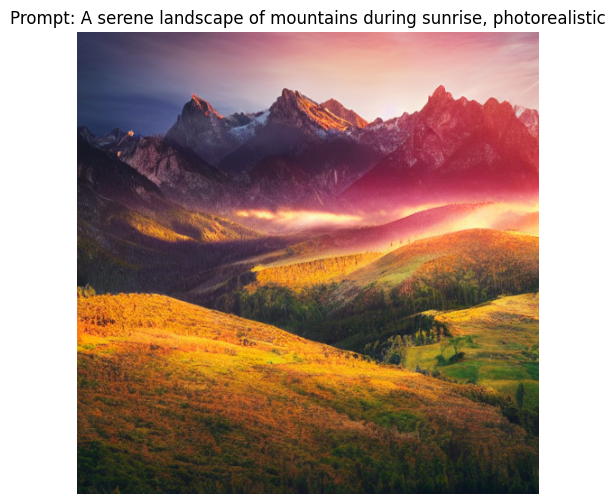

In [5]:
from PIL import Image  # 생성 결과 이미지 타입 힌트/처리용
import matplotlib.pyplot as plt  # 이미지 시각화

prompt = "A serene landscape of mountains during sunrise, photorealistic"

set_seed(100)  # 난수 시드 고정 (재현성)

# 텍스트 프롬프트로 이미지 생성
result = pipe(
    prompt,
    num_inference_steps = 50,  # 샘플링 스텝 수 (높으면 품질은 증가하나 시간이 많이 듬)
    guidance_scale = 7.5       # 프롬프트 반영 강도 (높으면 프롬프트에 충실해지나 부자연스러울 가능성)
)
image: Image.Image = result.images[0]  # 첫 번째 이미지 꺼내오기 (image 타입은 Image.Image)

plt.figure(figsize=(6, 6))
plt.imshow(image)  # 이미지 표시
plt.axis('off')    # 축 숨김
plt.title("Prompt: " + prompt)
plt.show()

In [6]:
image.save('photorealistic.png')  # 이미지 저장

Token indices sequence length is longer than the specified maximum sequence length for this model (156 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: [', holding a glowing sapphire sword that emits faint magical particles . the lighting is dramatic and volumetric , with warm orange sunlight piercing through soft clouds , creating god rays and long shadows . ultra - detailed textures , hyper - realistic materials , 8 k resolution , sharp focus , depth of field , cinematic color grading , epic scale composition , wide - angle lens , masterpiece , highly detailed , unreal engine render style .']
100%|██████████| 50/50 [05:43<00:00,  6.87s/it]


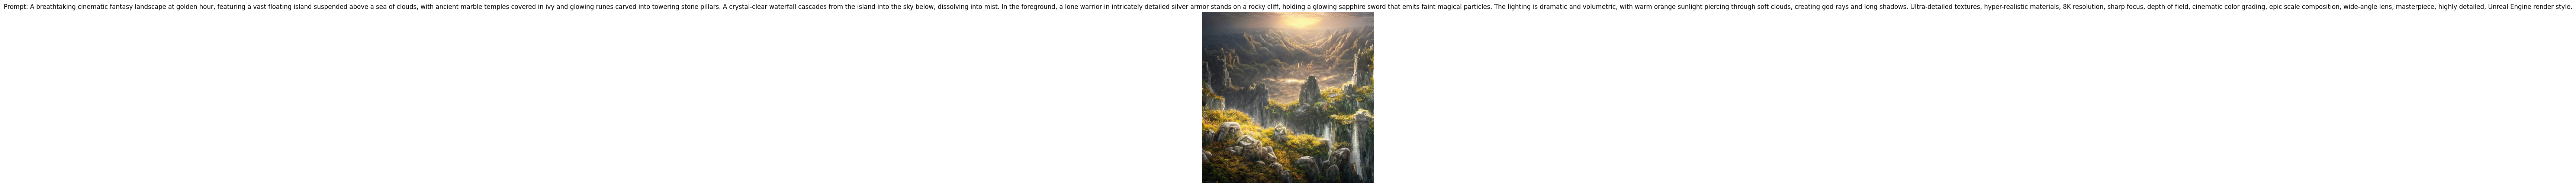

In [8]:
def generate_and_show(prompt: str):
    set_seed(100)  # 난수 시드 고정 (재현성)

    # 텍스트 프롬프트로 이미지 생성
    result = pipe(
        prompt,
        num_inference_steps = 50,  # 샘플링 스텝 수 (높으면 품질은 증가하나 시간이 많이 듬)
        guidance_scale = 7.5       # 프롬프트 반영 강도 (높으면 프롬프트에 충실해지나 부자연스러울 가능성)
    )
    image: Image.Image = result.images[0]  # 첫 번째 이미지 꺼내오기 (image 타입은 Image.Image)

    plt.figure(figsize=(6, 6))
    plt.imshow(image)  # 이미지 표시
    plt.axis('off')    # 축 숨김
    plt.title("Prompt: " + prompt)
    plt.show()

generate_and_show('A breathtaking cinematic fantasy landscape at golden hour, featuring a vast floating island suspended above a sea of clouds, with ancient marble temples covered in ivy and glowing runes carved into towering stone pillars. A crystal-clear waterfall cascades from the island into the sky below, dissolving into mist. In the foreground, a lone warrior in intricately detailed silver armor stands on a rocky cliff, holding a glowing sapphire sword that emits faint magical particles. The lighting is dramatic and volumetric, with warm orange sunlight piercing through soft clouds, creating god rays and long shadows. Ultra-detailed textures, hyper-realistic materials, 8K resolution, sharp focus, depth of field, cinematic color grading, epic scale composition, wide-angle lens, masterpiece, highly detailed, Unreal Engine render style.')